In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, chi2
from pathlib import Path
import numcosmo_sne.mcmc as mcmc
figDir = Path("../outputs/figs/")

# 1D Gaussian

In [2]:
def probGauss1D(theta, muTrue = 2.0, sigmaTrue=1.5):
    return -0.5 * ((theta[0] - muTrue) / sigmaTrue)**2

In [3]:
Nwalk = 200000
muTrue = 2.0
sigmaTrue = 1.5
print(f"mu = {muTrue:.4f}, sigma = {sigmaTrue:.4f}")

mu = 2.0000, sigma = 1.5000


In [4]:
chain, accepted, logp = mcmc.metropolisHastings(probGauss1D, np.array([0.0]), Nwalk, np.array([[4.0]]), seed=12345)
samples = chain[Nwalk//10:]
print(samples.shape)

(180000, 1)


mu = 2.0021, sigma = 1.5031, with acceptance rate of 62.71%


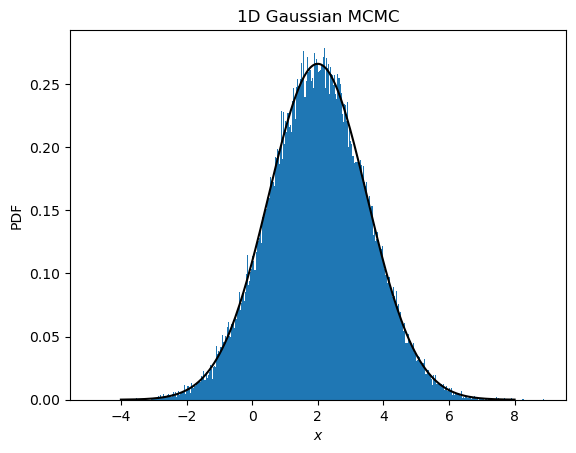

In [5]:
x = np.linspace(muTrue - 4*sigmaTrue, muTrue + 4*sigmaTrue, 300)
plt.hist(samples, bins=np.floor(np.sqrt(0.9*Nwalk)).astype(int), density=True)
plt.plot(x, np.exp(-0.5 * ((x - muTrue) / sigmaTrue)**2) / (sigmaTrue*np.sqrt(2*np.pi)), c="k")

muMCMC = np.mean(samples)
sigmaMCMC = np.std(samples, ddof=1)
acceptRate = np.mean(accepted)
print(f"mu = {muMCMC:.4f}, sigma = {sigmaMCMC:.4f}, with acceptance rate of {100*acceptRate:.2f}%")

plt.xlabel(r"$x$")
plt.ylabel("PDF")
plt.title("1D Gaussian MCMC")
plt.savefig(figDir / "1DgaussMCMC.png", dpi=300)
plt.show()

# Correlated 2D Gaussian

In [6]:
def probGauss2D(theta, mu=np.array([2.0, -1.0]), Cov=np.array([[2.25, 0.9],[0.9, 1.0]])):
    delta = theta - mu
    return -0.5 * delta @ np.linalg.solve(Cov, delta)

In [7]:
Nwalk = 2000000
muTrue  = np.array([2.0, -1.0])
covTrue = np.array([[2.25, 0.9],[0.9, 1.0]])
sigmaTrue = np.sqrt(np.diag(covTrue))

print("mu = ", muTrue, ", sigma = ", sigmaTrue)
print("covariance = \n", covTrue)

mu =  [ 2. -1.] , sigma =  [1.5 1. ]
covariance = 
 [[2.25 0.9 ]
 [0.9  1.  ]]


In [8]:
chain, accepted, logp = mcmc.metropolisHastings(probGauss2D, np.zeros(2), Nwalk, np.eye(2), seed=12345)
samples = chain[Nwalk//10:]
print(samples.shape)

(1800000, 2)


In [9]:
xsample = samples[:, 0]
ysample = samples[:, 1]

x = np.linspace(muTrue[0] - 4*sigmaTrue[0], muTrue[0] + 4*sigmaTrue[0], 300)
y = np.linspace(muTrue[1] - 4*sigmaTrue[1], muTrue[1] + 4*sigmaTrue[1], 300)

X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

pdf = multivariate_normal(mean=muTrue, cov=covTrue)
Z = pdf.pdf(pos)

probs = [0.6827, 0.9545, 0.9973]
q68 = chi2.ppf(probs[0], df=2) # 1 sigma
q95 = chi2.ppf(probs[1], df=2) # 2 sigma
q99 = chi2.ppf(probs[2], df=2) # 3 sigma

pdfMax = pdf.pdf(muTrue)

level68 = pdfMax * np.exp(-0.5*q68)
level95 = pdfMax * np.exp(-0.5*q95)
level99 = pdfMax * np.exp(-0.5*q99)

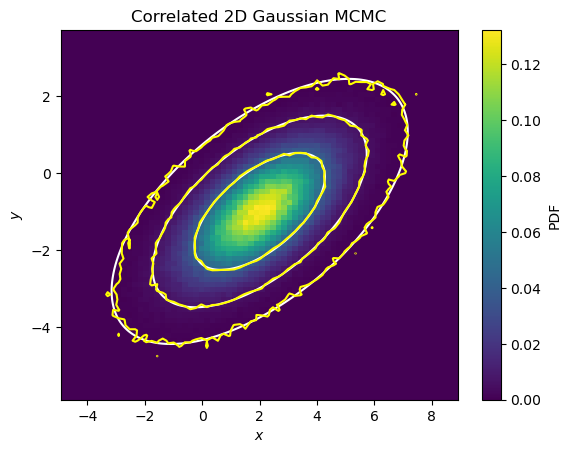

In [10]:
fig, ax = plt.subplots()
ax.contour(X, Y, Z, levels=[level99, level95, level68], colors="w")
H, xedges, yedges, cmesh = ax.hist2d(xsample, ysample, bins=2*np.floor((0.9*Nwalk)**0.25).astype(int), density=True)

# Isocontours of MCMC samples ------------------------------------------------
# Probability mass in each bin
dx = np.diff(xedges)
dy = np.diff(yedges)
mass = H * dx[:, None] * dy[None, :]

density_flat = H.ravel()
mass_flat = mass.ravel()

# Sort from highest to lowest density
order = np.argsort(density_flat)[::-1]

mass_sorted = mass_flat[order]
cumprob = np.cumsum(mass_sorted)

# Field containing enclosed probability associated with each bin
prob_flat = np.empty_like(cumprob)
prob_flat[order] = cumprob

P = prob_flat.reshape(H.shape)

# Drawing the isocontours -----------------------------------------------------
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xc, yc, indexing="xy")

cs = ax.contour(Xc, Yc, P.T, levels=probs, colors="yellow")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Correlated 2D Gaussian MCMC")
plt.colorbar(cmesh, label="PDF")
plt.savefig(figDir / "2DgaussMCMC.png", dpi=300)
plt.show()

In [11]:
muMCMC = np.mean(samples, axis=0)
sigmaMCMC = np.std(samples, axis=0, ddof=1)
acceptRate = np.mean(accepted)

print("mu = ", muMCMC, ", sigma = ", sigmaMCMC)
print("covariance = \n", np.cov(samples.T))
print(f"with acceptance rate of {100*acceptRate:.1f}%")

mu =  [ 2.00178117 -0.99958558] , sigma =  [1.49851822 1.00014438]
covariance = 
 [[2.24555685 0.89815517]
 [0.89815517 1.00028877]]
with acceptance rate of 55.0%
